# A (Very Short) Introduction to Machine Learning

In the next few sections, we will study **Gradient Descent** (arguably the most widely known and employed optimization method) and **Stochastic Gradient Descent** (a common variant of it). To motivate the introduction of these methods within the context of Machine Learning, we begin by presenting some fundamental concepts of Machine Learning from a mathematical perspective. In particular, we will discuss how the learning problem can be mathematically formulated, and we will outline the typical pipeline used to understand, design, and solve a Machine Learning problem.

Let's start with a widely accepted definition of **Machine Learning**:

> **Machine Learning (ML)** is the collection of techniques and algorithms that extract knowledge from data and use that knowledge to make accurate predictions.

## The learning problem

A learning problem involves extracting knowledge from a dataset of $N$ points:

$$
\{ (x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), \dots, (x^{(N)}, y^{(N)}) \}
$$

where each pair $(x^{(i)}, y^{(i)})$ consists of an input and its corresponding output. Think of the input data $x^{(i)} \in \mathbb{R}^d$ as the available information and the output data $y^{(i)} \in \mathbb{R}^s$ as the quantity we want to predict. The input dimension, $d$, represents the number of input features, while the output dimension, $s$, corresponds to the number of variables we aim to predict. To simplify things, we usually represent these as vectors of size $d$ and $s$, respectively.

For example, Machine Learning is widely used to predict house prices based on property characteristics. Suppose we have a dataset where each house is described by features such as:  

- $x_1$: Square footage  
- $x_2$: Number of bedrooms  
- $x_3$: Number of bathrooms  
- $x_4$: Distance to the city center  
- $x_5$: Age of the house  

The goal is to predict the selling price $y$ of a house given its features. Here, the input $x^{(i)} \in \mathbb{R}^5$ represents a vector of property attributes, and the output $y^{(i)} \in \mathbb{R}$ is the house price.  

A Machine Learning model, such as **linear regression**, learns a function $f_\Theta$ that maps inputs to outputs:  

$$
y = f_\Theta(x_1, x_2, x_3, x_4, x_5).
$$

Initially, the model **does not know** how these features influence the price. By **training** on past sales data, it finds patterns and estimates parameters (or weights) that best fit the data. Once trained, the model can predict the price of new houses that were not in the dataset.  

This simple example illustrates the core idea of learning: using past data to make future predictions. More generally, a Machine Learning model can be seen as a mathematical function that maps input features to an output of interest.

```{warning}
This setup assumes that all data is represented as real numbers (since both $x^{(i)}$ and $y^{(i)}$ are real-valued vectors). Handling non-numeric data requires a pre-processing step named *embedding*, which will be discussed in the following.
```

### Mathematical Formulation of Machine Learning Models  

At its core, a Machine Learning (ML) model is a function

$$
f_\Theta: \mathbb{R}^d \to \mathbb{R}^s
$$

that maps an input vector of length $d$ to an output vector of length $s$. The choice of $s$ depends on the application:

* If the model is used for **classification**, where an input belongs to one of $k$ categories, then $s = k$.
* If the model is used for **regression**, $s$ corresponds to the number of predicted values.
* If the model is used for **image reconstruction**, $s$ typically represents the number of pixels in the reconstructed image.

The model's knowledge is encoded in the vector $\Theta$, which represents its **parameters**. To better understand the role of parameters in an ML model, let's start with a simple example: Linear Regression.

Consider a basic model $f_\Theta$ with just two parameters, $\Theta_1$ and $\Theta_2$:

$$
f_\Theta(x) = \Theta_1 + \Theta_2 x.
$$

This equation describes a straight line where $\Theta_1$ is the intercept and $\Theta_2$ is the slope.

The core of the code is the function $f(\theta, x)$, which is defined as:$$f(\theta, x) = \theta_0 + \theta_1 x$$This is the standard equation for a straight line (often written as $y = mx + b$).In this context, it represents a simple linear model.The terms $\theta_0$ and $\theta_1$ are the parameters (or coefficients) of the model. Collectively, they are represented by the vector $\theta = (\theta_0, \theta_1)$.$\mathbf{\theta_0}$ is the y-intercept (the value of $y$ when $x=0$).$\mathbf{\theta_1}$ is the slope (how steep the line is and its direction).By changing the values of $\theta_0$ and $\theta_1$, you get a different straight line.

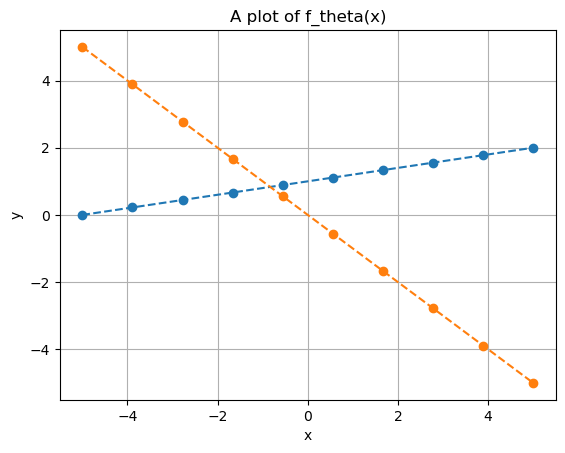

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameterized function f
def f(theta, x):
    return theta[0] + theta[1] * x

# Choose two different values for the parameters
theta = (1, 0.2)
theta2 = (0, -1)

# Visualize the model prediction in the range [-5, 5]
xx = np.linspace(-5, 5, 10)
yy = f(theta, xx)
yy2 = f(theta2, xx)

plt.plot(xx, yy, 'o--')
plt.plot(xx, yy2, 'o--')
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.title("A plot of f_theta(x)")
plt.show()

T
The new part of the code introduces `x_data` and `y_data` and adds a new `plt.plot()` command.

### 1\. Defining Input Data (`x_data`)

```python
x_data = np.linspace(-5, 5, 20)
```

  * `np.linspace(-5, 5, 20)` creates an array of **20 evenly spaced $x$-values** between -5 and 5.
      * *The difference from the previous `xx` (which had 10 points) is that this set is denser, as it represents the input locations for our simulated data.*

### 2\. Generating Output Data with Noise (`y_data`)

```python
y_data = 1 + 0.2 * x_data + np.random.normal(0, 0.5, x_data.shape)
```

This is the most crucial line, as it simulates real-world data by adding **random noise** to a perfect linear relationship.

  * **The "True" Relationship:** The first part, `1 + 0.2 * x_data`, represents a perfect straight line with an intercept of **1** and a slope of **0.2**. Notice that this perfect line is defined by the first set of parameters you used: $\theta = (1, 0.2)$.
      * *This is the underlying rule we are trying to discover.*
  * **Adding Random Noise:** The second part, `+ np.random.normal(0, 0.5, x_data.shape)`, is what makes the data **synthetic but realistic**.
      * `np.random.normal(0, 0.5, ...)` generates random numbers from a **normal (Gaussian) distribution**.
          * **0** is the **mean ($\mu$)** of the random numbers. This means the noise is centered around zero, so it doesn't systematically push all points up or down.
          * **0.5** is the **standard deviation ($\sigma$)**. This controls how spread out the noise is, or how much the data points deviate from the perfect line. A higher number would make the data look more scattered.
          * `x_data.shape` ensures that an array of random noise is generated with the exact same size as `x_data` (20 numbers).
      * *In a nutshell, this line takes the perfect line and adds a little random "wobble" to each point.*

### 3\. Plotting the Synthetic Data

```python
plt.plot(x_data, y_data, 'o')
```

  * This command plots the `x_data` and `y_data` pairs.
  * The format string `'o'` tells Matplotlib to plot these as **individual circular points** (a scatter plot) without connecting them with a line.

-----

## 🎯 The Big Picture

When you run all the code together, you see three things on the plot:

1.  **Line 1 (Dashed Blue):** The model prediction $y = 1 + 0.2x$ (based on $\theta$).
2.  **Line 2 (Dashed Orange):** The model prediction $y = 0 - 1x$ (based on $\theta_2$).
3.  **The Synthetic Data (Blue Circles):** The scattered points generated from the *perfect* line $y = 1 + 0.2x$ plus random noise.

The key takeaway is that **Line 1 is the perfect fit** for the underlying relationship of the synthetic data. The goal of a **linear regression algorithm** (which you often study next) is to find parameters $\theta$ that make the model line (like Line 2) move closer to and eventually match the underlying perfect line (like Line 1) by minimizing the distance to the data points.


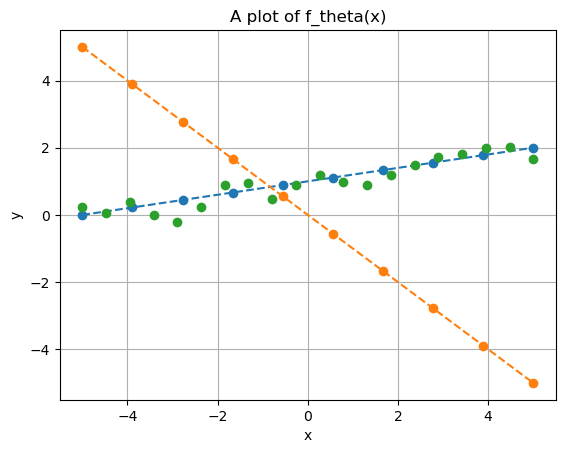

In [4]:
# Define synthetic datapoints
x_data = np.linspace(-5, 5, 20)
y_data = 1 + 0.2 * x_data + np.random.normal(0, 0.5, x_data.shape)

# Plot
plt.plot(xx, yy, 'o--')
plt.plot(xx, yy2, 'o--')
plt.plot(x_data, y_data, 'o')
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.title("A plot of f_theta(x)")
plt.show()

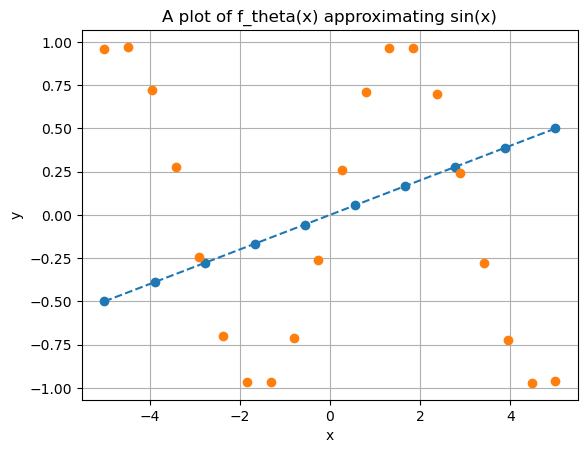

In [5]:
# Define synthetic datapoints
x_data = np.linspace(-5, 5, 20)
y_data = np.sin(x_data)

# Create a linear model approximation
xx = np.linspace(-5, 5, 10)
theta = (0, 0.1)
yy = f(theta, xx)

# Plot
plt.plot(xx, yy, 'o--')
plt.plot(x_data, y_data, 'o')
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.title("A plot of f_theta(x) approximating sin(x)")
plt.show()

### Collecting data
Collecting data is usually the step that takes the most effort in the design of a Machine Learning algorithm. In fact, given that our problem $y = f(x)$ is solvable and that it is **theoretically possible** to collect enough data about it, it is not always that **easy** in practice.

In particular, some data requires *time* to be collected (this is an example when working in biological or medical applications), and collect good quality data is hard. Indeed, we indeally want to use a clean dataset, where all the informations are presents, there are no missing values (usually referred to as `NaN`) and the informations does not contain noise. Most of the time, this is hopeless, and we will need to develop algorithms to standardize and clean up the data. The set of all those techniques is called **data cleaning**.

#### Kaggle
Luckily, for most of the tasks you can think of, you can find datasets on internet. For example, websites like [Kaggle](https://www.kaggle.com/) and [Google Datasets](https://datasetsearch.research.google.com/) can be helpful for that.

#### Datasets and NumPy Arrays

Datasets in `.csv` format are widely used, as they are easy to read and often come with clearly labeled rows and columns. However, from a mathematical and computational perspective, this format is not ideal for Machine Learning. In particular:

- Working with strings directly is inefficient.  
- Row and column names are not useful for learning algorithms.  
- Most ML algorithms expect data in the form of numeric vectors and matrices.  

For this reason, we almost always **convert datasets into matrices**, typically represented as NumPy arrays. This conversion is performed in two main steps:

1. **Encoding categorical (string) values into numbers**.  
2. **Converting the dataset into a NumPy array**.  

Suppose we have a categorical feature, such as *weather*, with possible values $\{ \text{sunny}, \text{rainy}, \text{cloudy}, \text{snowy} \}$. Since the number of possible values is limited, we can assign each category to a class.

Two classical encoding strategies are:

- **Integer Encoding**: Each class $C_k$ is mapped to an integer index $k$. A crucial drawback of this method is that it introduces an artificial ordering between categories. It is implemented in Python via:  

  ```
  from sklearn.preprocessing import LabelEncoder
  encoder = LabelEncoder()
  encoded = encoder.fit_transform(categories)
  ```

- **One-Hot Encoding**: Each class $C_k$ is mapped to the $k$-th canonical vector $e_k \in \mathbb{R}^K$, which is all zeros except for a single 1 at position $k$. It is implemented in Python via:  

  ```
  from sklearn.preprocessing import OneHotEncoder
  encoder = OneHotEncoder(sparse=False)
  encoded = encoder.fit_transform(categories.reshape(-1, 1))
  ```

After encoding, the dataset can be converted to a NumPy array with:  

```
import numpy as np
X = np.array(encoded_dataset)
```

The result is a matrix:

$$
X = [x_1, x_2, \ldots, x_N] \in \mathbb{R}^{d \times N},
$$

where each column $x_i \in \mathbb{R}^d$ is a datapoint with $d$ features, and $N$ is the number of samples. The corresponding labels are collected in a vector:

$$
Y = [y_1, y_2, \ldots, y_N]^T \in \mathbb{R}^N.
$$

#### Modern Embedding Strategies

While integer and one-hot encodings are simple and effective, they do not capture **semantic relationships** between categories. For example, in one-hot encoding, the vectors for *sunny* and *cloudy* are completely orthogonal, even though they are more similar to each other than to *snowy*.  

To address this limitation, **learned embeddings** are now widely used:

- In **Natural Language Processing (NLP)**, words or tokens are mapped to dense vectors in $\mathbb{R}^d$, called **word embeddings**. These vectors are learned from large corpora so that semantically related words (e.g., *king* and *queen*) are close in the embedding space.
- In modern **Large Language Models (LLMs)**, embeddings are used at multiple levels: for words, subwords, or tokens. These embeddings are **learned jointly with the model parameters**, allowing the network to discover relationships automatically during training.
- Similar strategies are used in **recommender systems** (e.g., embedding users and items) and **graph learning** (node embeddings).

In practice, this means that instead of manually encoding categories, we let the model **learn a representation** that is optimal for the task. In PyTorch, for example, this can be done with the `nn.Embedding` layer:

```
import torch
import torch.nn as nn

# Suppose we have 100 possible categories, mapped into 16-dimensional embeddings
embedding = nn.Embedding(num_embeddings=100, embedding_dim=16)

# Example: category index 5 -> embedding vector in R^16
category_index = torch.tensor([5])
vector = embedding(category_index)
```

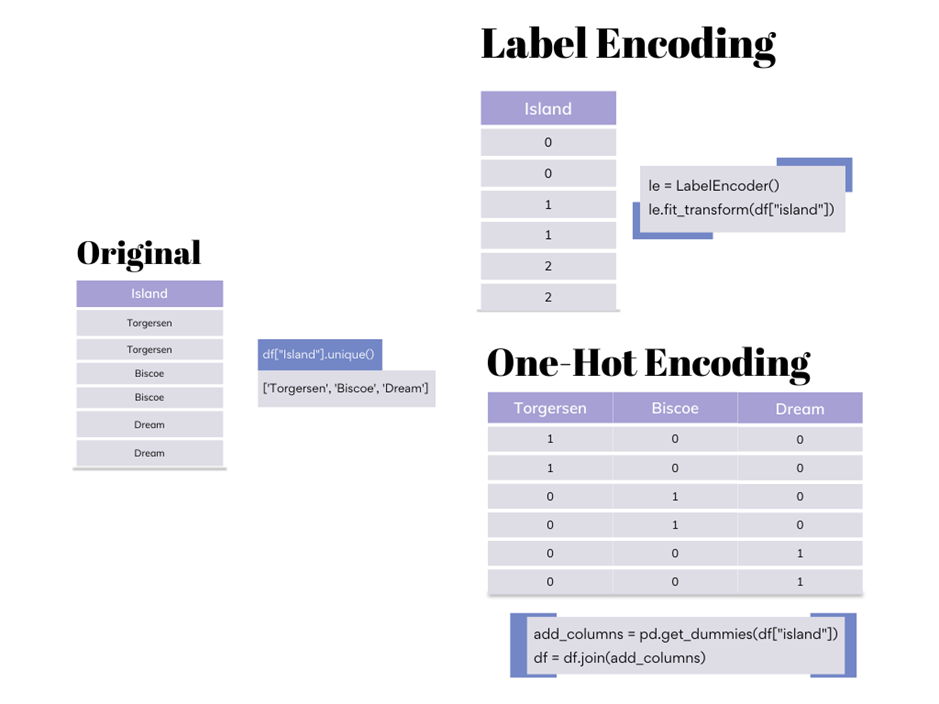

ref: https://medium.com/data-folks-indonesia/powering-up-your-pandas-part-ii-label-encoding-and-one-hot-encoding-dac0fce045da

The main reason we don't use Label Encoding on input features (like 'x' data) is that it creates a false and misleading ordinal relationship.Machine learning models are mathematical, and they will interpret these new numbers as having an order or rank. The model will "think" that:$$\text{Blue (2)} > \text{Green (1)} > \text{Red (0)}$$It might even learn that "Blue" is somehow twice as "Green" (since $2 = 2 \times 1$). This is almost always incorrect for nominal categories (categories with no intrinsic order), which can confuse your model and lead to poor performance.

When Should You Use Label Encoding?Even though it's bad for input features, Label Encoding is still the standard method for:Ordinal Data: When your categories do have a meaningful order (e.g., Small $\rightarrow$ 0, Medium $\rightarrow$ 1, Large $\rightarrow$ 2).The Target Variable (y): In classification problems, you almost always use Label Encoding for your output or target variable (the y_data in our examples). This is because the model just needs a unique numerical ID for each class it's trying to predict.

Modern Embedding Strategies
While integer and one-hot encodings are simple and effective, they do not capture semantic relationships between categories. For example, in one-hot encoding, the vectors for sunny and cloudy are completely orthogonal, even though they are more similar to each other than to snowy.

To address this limitation, learned embeddings are now widely used:

In Natural Language Processing (NLP), words or tokens are mapped to dense vectors in 
, called word embeddings. These vectors are learned from large corpora so that semantically related words (e.g., king and queen) are close in the embedding space.

In modern Large Language Models (LLMs), embeddings are used at multiple levels: for words, subwords, or tokens. These embeddings are learned jointly with the model parameters, allowing the network to discover relationships automatically during training.

Similar strategies are used in recommender systems (e.g., embedding users and items) and graph learning (node embeddings).

In practice, this means that instead of manually encoding categories, we let the model learn a representation that is optimal for the task. In PyTorch, for example, this can be done with the nn.Embedding layer:



In [ ]:
import torch
import torch.nn as nn

# Suppose we have 100 possible categories, mapped into 16-dimensional embeddings
embedding = nn.Embedding(num_embeddings=100, embedding_dim=16)

# Example: category index 5 -> embedding vector in R^16
category_index = torch.tensor([5])
vector = embedding(category_index)